# Анализ пользовательской воронки
## Цель

Оценить прохождение пользователей через этапы:

1. просмотр товара;
2. добавление товара в корзину;
3. покупка.

Сначала анализируется охват каждого события, затем строится строгая
последовательная воронка с учётом времени действий.

## Ограничения

- сессии пользователей в данных отсутствуют;
- стоимость заказов неизвестна;
- время указано в UTC;
- наблюдаемая покупка могла начаться до начала периода данных;
- действие на следующем этапе не всегда гарантирует наличие
  предыдущего события в доступной истории.

In [39]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid")

CURRENT_DIR = Path.cwd()

if (CURRENT_DIR / "data" / "processed").exists():
    PROJECT_DIR = CURRENT_DIR
elif (CURRENT_DIR.parent / "data" / "processed").exists():
    PROJECT_DIR = CURRENT_DIR.parent
else:
    raise FileNotFoundError(
        "Не удалось найти папку data/processed. "
        f"Текущая папка: {CURRENT_DIR}"
    )

PROCESSED_DIR = PROJECT_DIR / "data" / "processed"

print("Папка проекта:", PROJECT_DIR)

Папка проекта: C:\Users\Тимофей\PycharmProjects\ecommerce-customer-analysis


In [40]:
events = pd.read_csv(
    PROCESSED_DIR / "clean_events.csv",
    usecols=[
        "visitorid",
        "event",
        "itemid",
        "transactionid",
        "datetime"
    ],
    dtype={
        "visitorid": "int64",
        "event": "category",
        "itemid": "int64",
        "transactionid": "Int64"
    }
)

events["datetime"] = pd.to_datetime(
    events["datetime"],
    format="ISO8601",
    utc=True
).dt.as_unit("ns")

assert events["visitorid"].notna().all()
assert events["event"].notna().all()
assert events["itemid"].notna().all()
assert events["datetime"].notna().all()

print("Событий:", len(events))
print("Пользователей:", events["visitorid"].nunique())
print(
    "Период:",
    events["datetime"].min(),
    "—",
    events["datetime"].max()
)

Событий: 2755641
Пользователей: 1407580
Период: 2015-05-03 03:00:04.384000+00:00 — 2015-09-18 02:59:47.788000+00:00


_Бизнес-вопрос_: сколько пользователей совершало каждое действие и являются ли этапы воронки вложенными?

In [41]:
user_event_flags = (
    events
    .groupby(
        ["visitorid", "event"],
        observed=True
    )
    .size()
    .unstack(fill_value=0)
    .reindex(
        columns=["view", "addtocart", "transaction"],
        fill_value=0
    )
    .gt(0)
)

user_event_flags.columns = [
    "has_view",
    "has_cart",
    "has_purchase"
]

display(user_event_flags.head())

,has_view,has_cart,has_purchase
visitorid,,,
0,True,False,False
1,True,False,False
2,True,False,False
3,True,False,False
4,True,False,False


In [42]:
event_reach = pd.Series({
    "Все активные пользователи": len(user_event_flags),
    "Пользователи с просмотром": (
        user_event_flags["has_view"].sum()
    ),
    "Пользователи с корзиной": (
        user_event_flags["has_cart"].sum()
    ),
    "Пользователи с покупкой": (
        user_event_flags["has_purchase"].sum()
    )
})

display(event_reach)

Все активные пользователи    1407580
Пользователи с просмотром    1404179
Пользователи с корзиной        37722
Пользователи с покупкой        11719
dtype: int64

In [43]:
sequence_gaps = pd.Series({
    "Корзина без просмотра": (
        user_event_flags["has_cart"]
        & ~user_event_flags["has_view"]
    ).sum(),

    "Покупка без корзины": (
        user_event_flags["has_purchase"]
        & ~user_event_flags["has_cart"]
    ).sum(),

    "Покупка без просмотра": (
        user_event_flags["has_purchase"]
        & ~user_event_flags["has_view"]
    ).sum(),

    "Покупка без просмотра и корзины": (
        user_event_flags["has_purchase"]
        & ~user_event_flags["has_view"]
        & ~user_event_flags["has_cart"]
    ).sum()
})

display(sequence_gaps)

Корзина без просмотра              3321
Покупка без корзины                1143
Покупка без просмотра               428
Покупка без просмотра и корзины      80
dtype: int64

первый просмотр → последующая корзина → последующая покупка

In [44]:
first_view = (
    events.loc[
        events["event"] == "view",
        ["visitorid", "datetime"]
    ]
    .groupby("visitorid")["datetime"]
    .min()
    .rename("first_view_time")
)

cart_events = (
    events.loc[
        events["event"] == "addtocart",
        ["visitorid", "datetime"]
    ]
    .rename(columns={"datetime": "cart_time"})
    .join(first_view, on="visitorid")
)

carts_after_view = cart_events[
    cart_events["first_view_time"].notna()
    & (
        cart_events["cart_time"]
        >= cart_events["first_view_time"]
    )
]

first_cart_after_view = (
    carts_after_view
    .groupby("visitorid")["cart_time"]
    .min()
    .rename("first_cart_after_view_time")
)

In [45]:
purchase_events = (
    events.loc[
        events["event"] == "transaction",
        ["visitorid", "datetime"]
    ]
    .rename(columns={"datetime": "purchase_time"})
    .join(first_cart_after_view, on="visitorid")
)

purchases_after_cart = purchase_events[
    purchase_events["first_cart_after_view_time"].notna()
    & (
        purchase_events["purchase_time"]
        >= purchase_events["first_cart_after_view_time"]
    )
]

first_purchase_after_cart = (
    purchases_after_cart
    .groupby("visitorid")["purchase_time"]
    .min()
    .rename("first_purchase_after_cart_time")
)

In [46]:
strict_funnel = pd.Series({
    "view": len(first_view),
    "addtocart_after_view": len(first_cart_after_view),
    "transaction_after_cart": len(first_purchase_after_cart)
})

strict_funnel_rates = pd.Series({
    "view_to_cart": (
        strict_funnel["addtocart_after_view"]
        / strict_funnel["view"]
        * 100
    ),
    "cart_to_purchase": (
        strict_funnel["transaction_after_cart"]
        / strict_funnel["addtocart_after_view"]
        * 100
    ),
    "view_to_purchase": (
        strict_funnel["transaction_after_cart"]
        / strict_funnel["view"]
        * 100
    )
})

display(strict_funnel)
display(strict_funnel_rates.round(2))

assert (
    strict_funnel["view"]
    >= strict_funnel["addtocart_after_view"]
    >= strict_funnel["transaction_after_cart"]
)

view                      1404179
addtocart_after_view        32934
transaction_after_cart       9952
dtype: int64

view_to_cart         2.35
cart_to_purchase    30.22
view_to_purchase     0.71
dtype: float64

In [47]:
first_item_view = (
    events.loc[
        events["event"] == "view",
        ["visitorid", "itemid", "datetime"]
    ]
    .groupby(
        ["visitorid", "itemid"],
        sort=False
    )["datetime"]
    .min()
    .rename("first_item_view_time")
)

item_cart_events = (
    events.loc[
        events["event"] == "addtocart",
        ["visitorid", "itemid", "datetime"]
    ]
    .rename(columns={"datetime": "item_cart_time"})
    .join(
        first_item_view,
        on=["visitorid", "itemid"]
    )
)

item_carts_after_view = item_cart_events[
    item_cart_events["first_item_view_time"].notna()
    & (
        item_cart_events["item_cart_time"]
        >= item_cart_events["first_item_view_time"]
    )
]

first_item_cart_after_view = (
    item_carts_after_view
    .groupby(
        ["visitorid", "itemid"],
        sort=False
    )["item_cart_time"]
    .min()
    .rename("first_item_cart_after_view_time")
)

In [48]:
item_purchase_events = (
    events.loc[
        events["event"] == "transaction",
        ["visitorid", "itemid", "datetime"]
    ]
    .rename(columns={"datetime": "item_purchase_time"})
    .join(
        first_item_cart_after_view,
        on=["visitorid", "itemid"]
    )
)

item_purchases_after_cart = item_purchase_events[
    item_purchase_events[
        "first_item_cart_after_view_time"
    ].notna()
    & (
        item_purchase_events["item_purchase_time"]
        >= item_purchase_events[
            "first_item_cart_after_view_time"
        ]
    )
]

first_item_purchase_after_cart = (
    item_purchases_after_cart
    .groupby(
        ["visitorid", "itemid"],
        sort=False
    )["item_purchase_time"]
    .min()
    .rename("first_item_purchase_after_cart_time")
)

In [49]:
item_pair_funnel = pd.Series({
    "viewed_user_item_pairs": len(first_item_view),
    "carted_after_view_pairs": len(first_item_cart_after_view),
    "purchased_after_cart_pairs": len(
        first_item_purchase_after_cart
    )
})

item_pair_rates = pd.Series({
    "view_to_cart": (
        item_pair_funnel["carted_after_view_pairs"]
        / item_pair_funnel["viewed_user_item_pairs"]
        * 100
    ),
    "cart_to_purchase": (
        item_pair_funnel["purchased_after_cart_pairs"]
        / item_pair_funnel["carted_after_view_pairs"]
        * 100
    ),
    "view_to_purchase": (
        item_pair_funnel["purchased_after_cart_pairs"]
        / item_pair_funnel["viewed_user_item_pairs"]
        * 100
    )
})

display(item_pair_funnel)
display(item_pair_rates.round(2))

assert (
    item_pair_funnel["viewed_user_item_pairs"]
    >= item_pair_funnel["carted_after_view_pairs"]
    >= item_pair_funnel["purchased_after_cart_pairs"]
)

viewed_user_item_pairs        2132127
carted_after_view_pairs         45810
purchased_after_cart_pairs      16700
dtype: int64

view_to_cart         2.15
cart_to_purchase    36.45
view_to_purchase     0.78
dtype: float64

In [50]:
completed_item_funnel_users = (
    first_item_purchase_after_cart
    .index
    .get_level_values("visitorid")
    .nunique()
)

print(
    "Пользователей, завершивших хотя бы "
    "одну товарную воронку:",
    completed_item_funnel_users
)

Пользователей, завершивших хотя бы одну товарную воронку: 9642


In [51]:
item_journeys = pd.concat(
    [
        first_item_view,
        first_item_cart_after_view,
        first_item_purchase_after_cart
    ],
    axis=1
)

item_journeys["view_to_cart_hours"] = (
    item_journeys["first_item_cart_after_view_time"]
    - item_journeys["first_item_view_time"]
).dt.total_seconds() / 3600

item_journeys["cart_to_purchase_hours"] = (
    item_journeys["first_item_purchase_after_cart_time"]
    - item_journeys["first_item_cart_after_view_time"]
).dt.total_seconds() / 3600

item_journeys["view_to_purchase_hours"] = (
    item_journeys["first_item_purchase_after_cart_time"]
    - item_journeys["first_item_view_time"]
).dt.total_seconds() / 3600

assert (
    item_journeys["view_to_cart_hours"]
    .dropna()
    .ge(0)
    .all()
)

assert (
    item_journeys["cart_to_purchase_hours"]
    .dropna()
    .ge(0)
    .all()
)

In [52]:
transition_columns = [
    "view_to_cart_hours",
    "cart_to_purchase_hours",
    "view_to_purchase_hours"
]

transition_percentiles = (
    item_journeys[transition_columns]
    .quantile(
        [0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
    )
)

display(transition_percentiles.round(2))

,view_to_cart_hours,cart_to_purchase_hours,view_to_purchase_hours
0.25,0.01,0.04,0.07
0.50,0.02,0.07,0.16
0.75,0.11,0.19,0.76
0.90,1.87,0.84,23.48
0.95,34.55,4.44,112.75
0.99,415.91,133.68,600.75


In [53]:
time_thresholds = {
    "1 час": 1,
    "24 часа": 24,
    "7 дней": 24 * 7,
    "30 дней": 24 * 30
}

time_window_summary = pd.DataFrame({
    window_name: (
        item_journeys[transition_columns]
        .le(hours)
        .mean()
        .mul(100)
    )
    for window_name, hours in time_thresholds.items()
}).T

display(time_window_summary.round(2))

,view_to_cart_hours,cart_to_purchase_hours,view_to_purchase_hours
1 час,1.90,0.71,0.61
24 часа,2.03,0.76,0.71
7 дней,2.10,0.78,0.75
30 дней,2.14,0.78,0.78


In [54]:
time_thresholds = {
    "1 час": 1,
    "24 часа": 24,
    "7 дней": 24 * 7,
    "30 дней": 24 * 30
}

time_window_summary = pd.DataFrame({
    window_name: (
        item_journeys[transition_columns]
        .le(hours)
        .mean()
        .mul(100)
    )
    for window_name, hours in time_thresholds.items()
}).T

display(time_window_summary.round(2))

,view_to_cart_hours,cart_to_purchase_hours,view_to_purchase_hours
1 час,1.90,0.71,0.61
24 часа,2.03,0.76,0.71
7 дней,2.10,0.78,0.75
30 дней,2.14,0.78,0.78


In [55]:
windowed_funnel_rates = []

for window_name, hours in time_thresholds.items():
    view_to_cart_rate = (
        item_journeys["view_to_cart_hours"]
        .le(hours)
        .sum()
        / len(first_item_view)
        * 100
    )

    cart_to_purchase_rate = (
        item_journeys["cart_to_purchase_hours"]
        .le(hours)
        .sum()
        / len(first_item_cart_after_view)
        * 100
    )

    view_to_purchase_rate = (
        item_journeys["view_to_purchase_hours"]
        .le(hours)
        .sum()
        / len(first_item_view)
        * 100
    )

    windowed_funnel_rates.append({
        "window": window_name,
        "view_to_cart_rate": view_to_cart_rate,
        "cart_to_purchase_rate": cart_to_purchase_rate,
        "view_to_purchase_rate": view_to_purchase_rate
    })

windowed_funnel_rates = (
    pd.DataFrame(windowed_funnel_rates)
    .set_index("window")
)

display(windowed_funnel_rates.round(2))

,view_to_cart_rate,cart_to_purchase_rate,view_to_purchase_rate
window,,,
1 час,1.90,33.11,0.61
24 часа,2.03,35.55,0.71
7 дней,2.10,36.16,0.75
30 дней,2.14,36.40,0.78


In [56]:
completed_transition_speed = pd.DataFrame({
    window_name: {
        "view_to_cart": (
            item_journeys["view_to_cart_hours"]
            .dropna()
            .le(hours)
            .mean()
            * 100
        ),
        "cart_to_purchase": (
            item_journeys["cart_to_purchase_hours"]
            .dropna()
            .le(hours)
            .mean()
            * 100
        ),
        "view_to_purchase": (
            item_journeys["view_to_purchase_hours"]
            .dropna()
            .le(hours)
            .mean()
            * 100
        )
    }
    for window_name, hours in time_thresholds.items()
}).T

display(completed_transition_speed.round(2))

,view_to_cart,cart_to_purchase,view_to_purchase
1 час,88.40,90.83,77.26
24 часа,94.27,97.52,90.23
7 дней,97.77,99.20,96.23
30 дней,99.55,99.84,99.29


In [57]:
observation_end = events["datetime"].max()

censoring_adjusted_rates = []

for window_name, hours in time_thresholds.items():
    window = pd.Timedelta(hours=hours)
    cutoff = observation_end - window

    # Эти просмотренные пары имели полное окно наблюдения
    eligible_views = first_item_view[
        first_item_view <= cutoff
    ]

    # Эти корзины имели полное окно для последующей покупки
    eligible_carts = first_item_cart_after_view[
        first_item_cart_after_view <= cutoff
    ]

    view_to_cart_rate = (
        item_journeys.loc[
            eligible_views.index,
            "view_to_cart_hours"
        ]
        .le(hours)
        .sum()
        / len(eligible_views)
        * 100
    )

    cart_to_purchase_rate = (
        item_journeys.loc[
            eligible_carts.index,
            "cart_to_purchase_hours"
        ]
        .le(hours)
        .sum()
        / len(eligible_carts)
        * 100
    )

    view_to_purchase_rate = (
        item_journeys.loc[
            eligible_views.index,
            "view_to_purchase_hours"
        ]
        .le(hours)
        .sum()
        / len(eligible_views)
        * 100
    )

    censoring_adjusted_rates.append({
        "window": window_name,
        "eligible_view_pairs": len(eligible_views),
        "eligible_cart_pairs": len(eligible_carts),
        "view_to_cart_rate": view_to_cart_rate,
        "cart_to_purchase_rate": cart_to_purchase_rate,
        "view_to_purchase_rate": view_to_purchase_rate
    })

censoring_adjusted_rates = (
    pd.DataFrame(censoring_adjusted_rates)
    .set_index("window")
)

display(censoring_adjusted_rates.round(2))

,eligible_view_pairs,eligible_cart_pairs,view_to_cart_rate,cart_to_purchase_rate,view_to_purchase_rate
window,,,,,
1 час,2131744,45805,1.90,33.11,0.61
24 часа,2124281,45669,2.03,35.59,0.71
7 дней,2042310,44056,2.11,36.21,0.76
30 дней,1717946,37222,2.17,36.50,0.79


In [58]:
FUNNEL_WINDOW_HOURS = 7 * 24
funnel_cutoff = (
    observation_end
    - pd.Timedelta(hours=FUNNEL_WINDOW_HOURS)
)

eligible_view_pairs = first_item_view[
    first_item_view <= funnel_cutoff
]

seven_day_journeys = item_journeys.loc[
    eligible_view_pairs.index
].copy()

cart_within_7d = (
    seven_day_journeys["view_to_cart_hours"]
    .le(FUNNEL_WINDOW_HOURS)
)

purchase_within_7d = (
    seven_day_journeys["view_to_purchase_hours"]
    .le(FUNNEL_WINDOW_HOURS)
)

seven_day_funnel = pd.Series({
    "Просмотр": len(seven_day_journeys),
    "Корзина за 7 дней": cart_within_7d.sum(),
    "Покупка за 7 дней": purchase_within_7d.sum()
})

display(seven_day_funnel)

Просмотр             2042310
Корзина за 7 дней      43153
Покупка за 7 дней      15525
dtype: int64

In [59]:
seven_day_rates = pd.Series({
    "Просмотр → корзина": (
        seven_day_funnel["Корзина за 7 дней"]
        / seven_day_funnel["Просмотр"]
        * 100
    ),

    "Корзина → покупка": (
        seven_day_funnel["Покупка за 7 дней"]
        / seven_day_funnel["Корзина за 7 дней"]
        * 100
    ),

    "Просмотр → покупка": (
        seven_day_funnel["Покупка за 7 дней"]
        / seven_day_funnel["Просмотр"]
        * 100
    )
})

display(seven_day_rates.round(2))

assert (
    seven_day_funnel["Просмотр"]
    >= seven_day_funnel["Корзина за 7 дней"]
    >= seven_day_funnel["Покупка за 7 дней"]
)

Просмотр → корзина     2.11
Корзина → покупка     35.98
Просмотр → покупка     0.76
dtype: float64

In [60]:
completed_7d_pairs = seven_day_journeys[
    purchase_within_7d
]

completed_7d_users = (
    completed_7d_pairs
    .index
    .get_level_values("visitorid")
    .nunique()
)

print(
    "Пользователей с завершённой "
    "семидневной товарной воронкой:",
    completed_7d_users
)

Пользователей с завершённой семидневной товарной воронкой: 9052


In [61]:
funnel_summary = pd.DataFrame({
    "stage": [
        "Просмотр",
        "Корзина за 7 дней",
        "Покупка за 7 дней"
    ],
    "pairs_count": [
        seven_day_funnel["Просмотр"],
        seven_day_funnel["Корзина за 7 дней"],
        seven_day_funnel["Покупка за 7 дней"]
    ],
    "conversion_from_previous": [
        100,
        seven_day_rates["Просмотр → корзина"],
        seven_day_rates["Корзина → покупка"]
    ],
    "conversion_from_view": [
        100,
        seven_day_rates["Просмотр → корзина"],
        seven_day_rates["Просмотр → покупка"]
    ]
})

funnel_summary["dropoff_count"] = [
    0,
    (
        seven_day_funnel["Просмотр"]
        - seven_day_funnel["Корзина за 7 дней"]
    ),
    (
        seven_day_funnel["Корзина за 7 дней"]
        - seven_day_funnel["Покупка за 7 дней"]
    )
]

funnel_summary["dropoff_rate"] = (
    100
    - funnel_summary["conversion_from_previous"]
)

display(funnel_summary.round(2))

,stage,pairs_count,conversion_from_previous,conversion_from_view,dropoff_count,dropoff_rate
0,Просмотр,2042310,100.00,100.00,0,0.00
1,Корзина за 7 дней,43153,2.11,2.11,1999157,97.89
2,Покупка за 7 дней,15525,35.98,0.76,27628,64.02


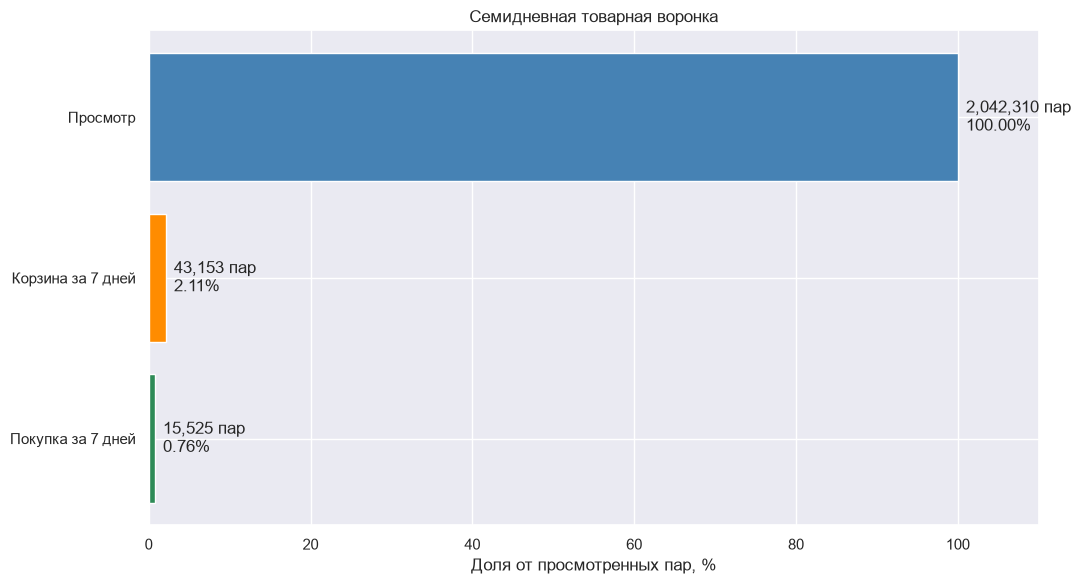

In [62]:
fig, ax = plt.subplots(figsize=(11, 6))

bars = ax.barh(
    funnel_summary["stage"],
    funnel_summary["conversion_from_view"],
    color=["steelblue", "darkorange", "seagreen"]
)

ax.invert_yaxis()
ax.set_title("Семидневная товарная воронка")
ax.set_xlabel("Доля от просмотренных пар, %")

for bar, (_, row) in zip(
    bars,
    funnel_summary.iterrows()
):
    ax.text(
        bar.get_width() + 1,
        bar.get_y() + bar.get_height() / 2,
        (
            f'{row["pairs_count"]:,.0f} пар\n'
            f'{row["conversion_from_view"]:.2f}%'
        ),
        va="center"
    )

ax.set_xlim(0, 110)
plt.tight_layout()
plt.show()

**Семидневная товарная воронка**

Воронка рассчитана на уровне уникальных пар «пользователь–товар».
В анализ включены только пары, имевшие полные семь дней наблюдения
после первого просмотра

Из 2 042 310 просмотренных пар 43 153, или 2,11%, дошли до корзины
в течение семи дней. Покупкой завершились 15 525 пар — 35,98% пар
с корзиной и 0,76% всех просмотренных пар

Хотя бы одну товарную воронку завершили 9 052 пользователя.
Главным узким местом является переход от просмотра к добавлению
в корзину. Результаты описывают поведение в данных, но не позволяют
определить причины потерь без информации о цене, наличии товара,
интерфейсе и источниках трафика

_Бизнес-вопрос_: стабильна ли товарная воронка во времени или ее показатели менялись между месячными когортами?

In [63]:
monthly_pair_funnel = (
    seven_day_journeys
    .reset_index()
)

monthly_pair_funnel["view_month"] = (
    monthly_pair_funnel["first_item_view_time"]
    .dt.strftime("%Y-%m")
)

monthly_pair_funnel["cart_within_7d"] = (
    monthly_pair_funnel["view_to_cart_hours"]
    .le(FUNNEL_WINDOW_HOURS)
)

monthly_pair_funnel["purchase_within_7d"] = (
    monthly_pair_funnel["view_to_purchase_hours"]
    .le(FUNNEL_WINDOW_HOURS)
)

monthly_funnel = (
    monthly_pair_funnel
    .groupby("view_month")
    .agg(
        viewed_pairs=("itemid", "size"),
        viewed_users=("visitorid", "nunique"),
        carted_pairs=("cart_within_7d", "sum"),
        purchased_pairs=("purchase_within_7d", "sum")
    )
)

In [64]:
monthly_funnel["view_to_cart_rate"] = (
    monthly_funnel["carted_pairs"]
    / monthly_funnel["viewed_pairs"]
    * 100
)

monthly_funnel["cart_to_purchase_rate"] = (
    monthly_funnel["purchased_pairs"]
    / monthly_funnel["carted_pairs"]
    * 100
)

monthly_funnel["view_to_purchase_rate"] = (
    monthly_funnel["purchased_pairs"]
    / monthly_funnel["viewed_pairs"]
    * 100
)

display(monthly_funnel.round(2))

,viewed_pairs,viewed_users,carted_pairs,purchased_pairs,view_to_cart_rate,cart_to_purchase_rate,view_to_purchase_rate
view_month,,,,,,,
2015-05,457015,306915,9798,3413,2.14,34.83,0.75
2015-06,463924,310745,10421,3772,2.25,36.20,0.81
2015-07,543547,373247,11040,4122,2.03,37.34,0.76
2015-08,429962,307241,8996,3193,2.09,35.49,0.74
2015-09,147862,107103,2898,1025,1.96,35.37,0.69


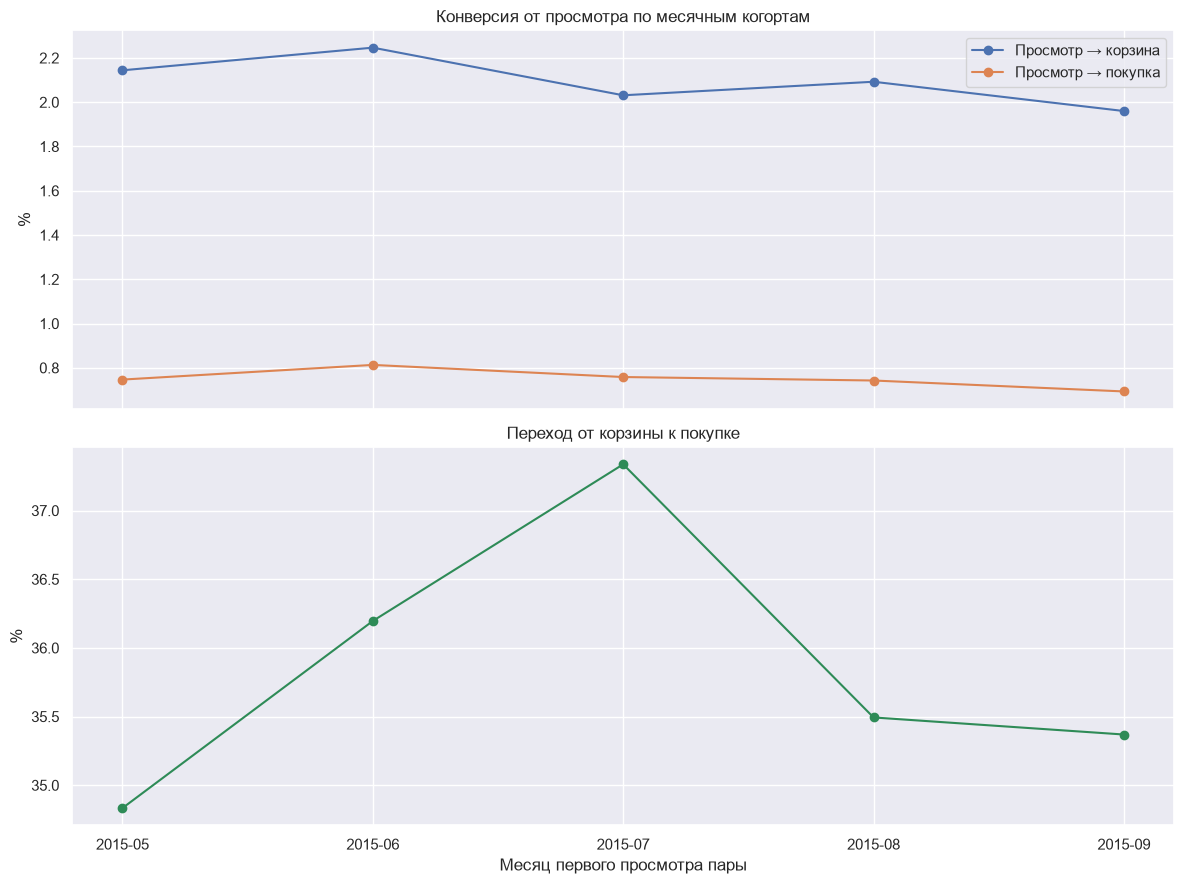

In [65]:
fig, axes = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(12, 9),
    sharex=True
)

axes[0].plot(
    monthly_funnel.index,
    monthly_funnel["view_to_cart_rate"],
    marker="o",
    label="Просмотр → корзина"
)

axes[0].plot(
    monthly_funnel.index,
    monthly_funnel["view_to_purchase_rate"],
    marker="o",
    label="Просмотр → покупка"
)

axes[0].set_title("Конверсия от просмотра по месячным когортам")
axes[0].set_ylabel("%")
axes[0].legend()

axes[1].plot(
    monthly_funnel.index,
    monthly_funnel["cart_to_purchase_rate"],
    marker="o",
    color="seagreen"
)

axes[1].set_title("Переход от корзины к покупке")
axes[1].set_xlabel("Месяц первого просмотра пары")
axes[1].set_ylabel("%")

plt.tight_layout()
plt.show()

**Вывод**

Воронка улучшалась с мая по июнь–июль, после чего показатели начали снижаться. Самый низкий итоговый переход от просмотра к покупке наблюдается в сентябрьской когорте. При этом сентябрь содержит только первые просмотры до 11 сентября, поэтому результат описывает начало месяца, а не весь сентябрь.

In [66]:
from scipy.stats import chi2_contingency

def test_monthly_difference(data, success_column, total_column):
    success = data[success_column].to_numpy()
    failure = (
        data[total_column] - data[success_column]
    ).to_numpy()

    contingency_table = np.column_stack([
        success,
        failure
    ])

    chi2, p_value, dof, expected = chi2_contingency(
        contingency_table
    )

    observations = contingency_table.sum()

    cramers_v = np.sqrt(
        chi2
        / (
            observations
            * min(
                contingency_table.shape[0] - 1,
                contingency_table.shape[1] - 1
            )
        )
    )

    return {
        "chi2": chi2,
        "p_value": p_value,
        "degrees_of_freedom": dof,
        "cramers_v": cramers_v
    }


In [67]:
monthly_tests = pd.DataFrame({
    "view_to_cart": test_monthly_difference(
        monthly_funnel,
        success_column="carted_pairs",
        total_column="viewed_pairs"
    ),

    "cart_to_purchase": test_monthly_difference(
        monthly_funnel,
        success_column="purchased_pairs",
        total_column="carted_pairs"
    ),

    "view_to_purchase": test_monthly_difference(
        monthly_funnel,
        success_column="purchased_pairs",
        total_column="viewed_pairs"
    )
}).T

display(monthly_tests)

,chi2,p_value,degrees_of_freedom,cramers_v
view_to_cart,77.219054,6.759197e-16,4.0,0.006149
cart_to_purchase,16.020374,2.991946e-03,4.0,0.019268
view_to_purchase,28.853493,8.371782e-06,4.0,0.003759


In [68]:
for transition, row in monthly_tests.iterrows():
    print(
        transition,
        "| p-value:",
        f'{row["p_value"]:.3e}',
        "| Cramer's V:",
        f'{row["cramers_v"]:.4f}'
    )

view_to_cart | p-value: 6.759e-16 | Cramer's V: 0.0061
cart_to_purchase | p-value: 2.992e-03 | Cramer's V: 0.0193
view_to_purchase | p-value: 8.372e-06 | Cramer's V: 0.0038


**Вывод**

Критерий хи-квадрат обнаружил статистически значимые различия
между месячными когортами для всех этапов воронки (p-value < 0,05).
Однако значения критерия Крамера находятся в диапазоне 0,0038–0,0193,
что указывает на крайне слабую связь месяца первого просмотра
с прохождением воронки

Следовательно, месячные колебания существуют, но их практический
масштаб невелик. Статистическая значимость в данном случае во многом
обусловлена большим количеством наблюдений

_Гипотеза_: зависит ли прохождение семидневной товарной воронки от дня недели первого просмотра?

In [69]:
weekday_names = {
    0: "Понедельник",
    1: "Вторник",
    2: "Среда",
    3: "Четверг",
    4: "Пятница",
    5: "Суббота",
    6: "Воскресенье"
}

weekday_order = list(weekday_names.values())

weekday_pair_funnel = (
    seven_day_journeys
    .reset_index()
)

weekday_pair_funnel["weekday_number"] = (
    weekday_pair_funnel[
        "first_item_view_time"
    ].dt.dayofweek
)

weekday_pair_funnel["weekday"] = (
    weekday_pair_funnel["weekday_number"]
    .map(weekday_names)
)

weekday_pair_funnel["weekday"] = pd.Categorical(
    weekday_pair_funnel["weekday"],
    categories=weekday_order,
    ordered=True
)

weekday_pair_funnel["cart_within_7d"] = (
    weekday_pair_funnel["view_to_cart_hours"]
    .le(FUNNEL_WINDOW_HOURS)
)

weekday_pair_funnel["purchase_within_7d"] = (
    weekday_pair_funnel["view_to_purchase_hours"]
    .le(FUNNEL_WINDOW_HOURS)
)

In [70]:
weekday_funnel = (
    weekday_pair_funnel
    .groupby(
        "weekday",
        observed=False
    )
    .agg(
        viewed_pairs=("itemid", "size"),
        viewed_users=("visitorid", "nunique"),
        carted_pairs=("cart_within_7d", "sum"),
        purchased_pairs=("purchase_within_7d", "sum")
    )
)

weekday_funnel["view_to_cart_rate"] = (
    weekday_funnel["carted_pairs"]
    / weekday_funnel["viewed_pairs"]
    * 100
)

weekday_funnel["cart_to_purchase_rate"] = (
    weekday_funnel["purchased_pairs"]
    / weekday_funnel["carted_pairs"]
    * 100
)

weekday_funnel["view_to_purchase_rate"] = (
    weekday_funnel["purchased_pairs"]
    / weekday_funnel["viewed_pairs"]
    * 100
)

display(weekday_funnel.round(2))

,viewed_pairs,viewed_users,carted_pairs,purchased_pairs,view_to_cart_rate,cart_to_purchase_rate,view_to_purchase_rate
weekday,,,,,,,
Понедельник,322797,229831,7099,2716,2.20,38.26,0.84
Вторник,328972,232702,7292,2759,2.22,37.84,0.84
Среда,322535,229797,7353,2856,2.28,38.84,0.89
Четверг,313873,224130,6960,2546,2.22,36.58,0.81
Пятница,278874,200552,5659,1902,2.03,33.61,0.68
Суббота,226464,165355,4174,1287,1.84,30.83,0.57
Воскресенье,248795,180490,4616,1459,1.86,31.61,0.59


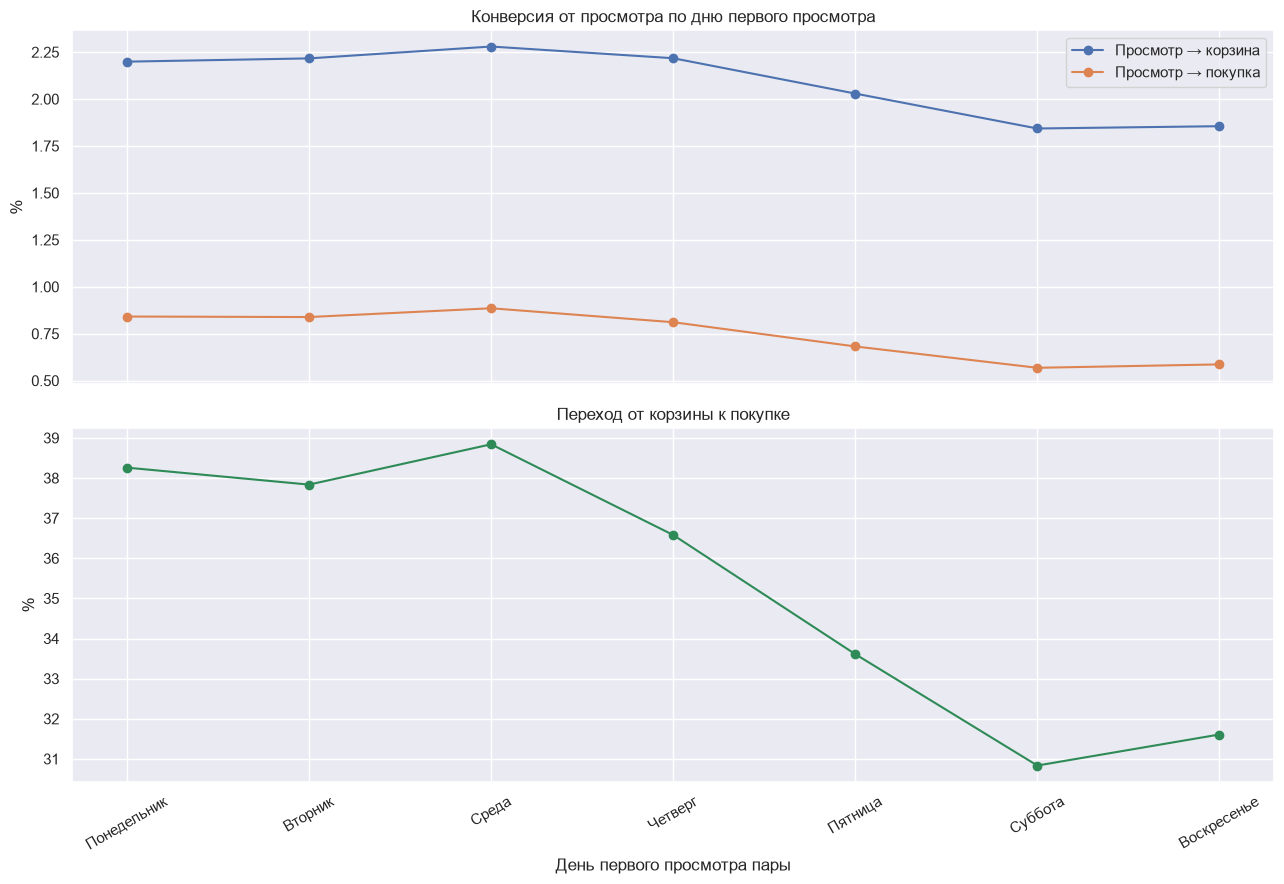

In [71]:
fig, axes = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(13, 9),
    sharex=True
)

axes[0].plot(
    weekday_funnel.index,
    weekday_funnel["view_to_cart_rate"],
    marker="o",
    label="Просмотр → корзина"
)

axes[0].plot(
    weekday_funnel.index,
    weekday_funnel["view_to_purchase_rate"],
    marker="o",
    label="Просмотр → покупка"
)

axes[0].set_title(
    "Конверсия от просмотра по дню первого просмотра"
)
axes[0].set_ylabel("%")
axes[0].legend()

axes[1].plot(
    weekday_funnel.index,
    weekday_funnel["cart_to_purchase_rate"],
    marker="o",
    color="seagreen"
)

axes[1].set_title("Переход от корзины к покупке")
axes[1].set_xlabel("День первого просмотра пары")
axes[1].set_ylabel("%")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

**Воронка по дням недели**

Наиболее результативные товарные пути начинаются в среду:
2,28% просмотренных пар доходят до корзины, 38,84% пар с корзиной -
до покупки, а полная конверсия составляет 0,89%

Наиболее слабые результаты наблюдаются в выходные. Для путей,
начавшихся в субботу, показатели снижаются до 1,84%, 30,83% и 0,57%
соответственно

Снижение происходит на обоих этапах воронки. По сравнению со средой
субботний переход к корзине ниже примерно на 19%, а переход от корзины
к покупке - примерно на 21%. Следовательно, слабый результат выходных
нельзя объяснить только одним этапом

In [72]:
def test_group_difference(
    data,
    success_column,
    total_column
):
    success = data[success_column].to_numpy()

    failure = (
        data[total_column]
        - data[success_column]
    ).to_numpy()

    contingency_table = np.column_stack([
        success,
        failure
    ])

    chi2, p_value, dof, expected = chi2_contingency(
        contingency_table
    )

    observations = contingency_table.sum()

    cramers_v = np.sqrt(
        chi2
        / (
            observations
            * min(
                contingency_table.shape[0] - 1,
                contingency_table.shape[1] - 1
            )
        )
    )

    return {
        "chi2": chi2,
        "p_value": p_value,
        "degrees_of_freedom": dof,
        "cramers_v": cramers_v
    }

In [73]:
weekday_tests = pd.DataFrame({
    "view_to_cart": test_group_difference(
        weekday_funnel,
        success_column="carted_pairs",
        total_column="viewed_pairs"
    ),

    "cart_to_purchase": test_group_difference(
        weekday_funnel,
        success_column="purchased_pairs",
        total_column="carted_pairs"
    ),

    "view_to_purchase": test_group_difference(
        weekday_funnel,
        success_column="purchased_pairs",
        total_column="viewed_pairs"
    )
}).T

display(weekday_tests)

for transition, row in weekday_tests.iterrows():
    print(
        transition,
        "| p-value:",
        f'{row["p_value"]:.3e}',
        "| Cramer's V:",
        f'{row["cramers_v"]:.4f}'
    )

,chi2,p_value,degrees_of_freedom,cramers_v
view_to_cart,257.660711,9.450085e-53,6.0,0.011232
cart_to_purchase,154.242779,9.799120e-31,6.0,0.059786
view_to_purchase,365.700608,6.561960e-76,6.0,0.013381


view_to_cart | p-value: 9.450e-53 | Cramer's V: 0.0112
cart_to_purchase | p-value: 9.799e-31 | Cramer's V: 0.0598
view_to_purchase | p-value: 6.562e-76 | Cramer's V: 0.0134


Критерий хи-квадрат обнаружил статистически значимую связь дня
первого просмотра со всеми этапами семидневной товарной воронки
(p-value < 0,05)

Связь дня недели с прохождением воронки сильнее, чем связь месяца,
однако размер эффекта остаётся небольшим. Максимальное значение
критерия Крамера получено для перехода от корзины к покупке - 0,0598

Следовательно, недельная сезонность является устойчивым, но не
доминирующим фактором. Она не объясняет поведение пользователей
полностью и не доказывает причинного влияния дня недели

In [74]:
funnel_summary.to_csv(
    PROCESSED_DIR / "funnel_summary.csv",
    index=False
)

monthly_funnel.reset_index().to_csv(
    PROCESSED_DIR / "monthly_funnel.csv",
    index=False
)

weekday_funnel.reset_index().to_csv(
    PROCESSED_DIR / "weekday_funnel.csv",
    index=False
)

statistical_tests = pd.concat(
    {
        "month": monthly_tests,
        "weekday": weekday_tests
    },
    names=["grouping", "transition"]
).reset_index()

statistical_tests.to_csv(
    PROCESSED_DIR / "funnel_statistical_tests.csv",
    index=False
)

print("Итоговые таблицы воронки сохранены")

Итоговые таблицы воронки сохранены
